
# Task 2: Exploratory Data Analysis

## Web Scraping Dataset Books to Scrape

### Questions to investigate

1. How many books are in the dataset and what variables are available?
2. What are the typical book prices?
3. How are book prices distributed?
4. Which books are the cheapest and most expensive?
5. Are there unusual price values or potential outliers?
6. How are books distributed across ratings?
7. Is there evidence of a relationship between book rating and price?
8. What data-quality issues need to be addressed before further analysis?



## 1. Import Libraries

We use:

- Pandas for data manipulation and analysis
- NumPy for numerical operations
- Matplotlib for visualization
- SciPy for statistical testing


In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


In [49]:
plt.rcParams.update({
    "figure.facecolor": "#F5F0E6",
    "axes.facecolor": "#F5F0E6",
    "axes.edgecolor": "#2F2A26",
    "axes.labelcolor": "#2F2A26",
    "xtick.color": "#2F2A26",
    "ytick.color": "#2F2A26",
    "text.color": "#2F2A26",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.2
})


## 2. Load the Dataset

Place the CSV created in **Task 1** in the same folder as this notebook.

The notebook first looks for `books_dataset.csv`. If that file is not found, it automatically collects the Books to Scrape data so the notebook can still be executed from start to finish.

**For the final submission, use the CSV produced by your Task 1 whenever possible.**


In [50]:

from pathlib import Path

csv_path = Path("books_dataset.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded Task 1 dataset: {csv_path}")
else:
    print("books_dataset.csv was not found.")
    print("Creating a complete Books to Scrape dataset as a fallback...")

    import requests
    from bs4 import BeautifulSoup
    import time

    records = []

    for page in range(1, 51):
        url = f"https://books.toscrape.com/catalogue/page-{page}.html"
        response = requests.get(url, timeout=20)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        for book in soup.select("article.product_pod"):
            title = book.select_one("h3 a")["title"].strip()
            price_text = book.select_one(".price_color").get_text(strip=True)
            availability = book.select_one(".availability").get_text(" ", strip=True)

            rating_tag = book.select_one("p.star-rating")
            rating = None
            if rating_tag:
                rating_classes = rating_tag.get("class", [])
                rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
                for word, value in rating_map.items():
                    if word in rating_classes:
                        rating = value
                        break

            records.append({
                "Title": title,
                "Price": price_text,
                "Rating": rating,
                "Availability": availability
            })

        time.sleep(0.2)

    df = pd.DataFrame(records)
    df.to_csv("books_dataset.csv", index=False)
    print("Fallback dataset saved as books_dataset.csv")

print(f"Dataset shape: {df.shape}")
df.head()


Loaded Task 1 dataset: books_dataset.csv
Dataset shape: (1000, 4)


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,3,In stock
1,Tipping the Velvet,Â£53.74,1,In stock
2,Soumission,Â£50.10,1,In stock
3,Sharp Objects,Â£47.82,4,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock



## 3. Understand the Data Structure

First, inspect the number of observations, variables, column names, and data types.


In [51]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Number of rows: 1000
Number of columns: 4

Column names:
['Title', 'Price', 'Rating', 'Availability']

Data types:
Title           object
Price           object
Rating           int64
Availability    object
dtype: object

First 5 rows:


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,3,In stock
1,Tipping the Velvet,Â£53.74,1,In stock
2,Soumission,Â£50.10,1,In stock
3,Sharp Objects,Â£47.82,4,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock



### Initial observation

The dataset should contain information about books collected from the public Books to Scrape website. The exact number of rows depends on the dataset collected in Task 1.



## 4. Check Missing Values and Duplicates

Missing values and duplicate records can affect the reliability of later analysis.


In [52]:

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent.round(2)
})

print("Missing-value summary:")
display(missing_table)

print("Number of duplicate rows:", df.duplicated().sum())


Missing-value summary:


,Missing Values,Missing Percentage
Title,0,0.0
Price,0,0.0
Rating,0,0.0
Availability,0,0.0


Number of duplicate rows: 0



## 5. Clean and Prepare Numeric Variables

Price is often scraped as text because it contains the `£` symbol. Convert it to a numeric variable before calculating statistics.

The code also handles common column-name variations so it can work with slightly different Task 1 datasets.


In [53]:
df["Price_GBP"] = (
    df["Price"]
    .astype(str)
    .str.replace("Â£", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df[["Price", "Price_GBP"]].head(10))

     Price  Price_GBP
0  Â£51.77      51.77
1  Â£53.74      53.74
2  Â£50.10      50.10
3  Â£47.82      47.82
4  Â£54.23      54.23
5  Â£22.65      22.65
6  Â£33.34      33.34
7  Â£17.93      17.93
8  Â£22.60      22.60
9  Â£52.15      52.15



## 6. Descriptive Statistics

These statistics describe the center and spread of book prices.


In [54]:

price_stats = df["Price_GBP"].describe()

print("Descriptive statistics for book price:")
display(price_stats.to_frame(name="Price (£)").round(2))


Descriptive statistics for book price:


,Price (£)
count,1000.00
mean,35.07
std,14.45
min,10.00
25%,22.11
50%,35.98
75%,47.46
max,59.99



### Questions answered

- **Mean:** average book price
- **Median:** middle book price
- **Standard deviation:** how widely prices vary
- **Minimum/maximum:** cheapest and most expensive observations
- **25th/75th percentiles:** the central 50% price range



## 7. Price Distribution

A histogram helps identify the most common price range and whether the distribution is symmetric or skewed.


In [55]:
print(df[["Price", "Price_GBP"]].head(10))
print("\nPrice_GBP data type:", df["Price_GBP"].dtype)
print("Number of valid prices:", df["Price_GBP"].notna().sum())
print("Number of missing prices:", df["Price_GBP"].isna().sum())

     Price  Price_GBP
0  Â£51.77      51.77
1  Â£53.74      53.74
2  Â£50.10      50.10
3  Â£47.82      47.82
4  Â£54.23      54.23
5  Â£22.65      22.65
6  Â£33.34      33.34
7  Â£17.93      17.93
8  Â£22.60      22.60
9  Â£52.15      52.15

Price_GBP data type: float64
Number of valid prices: 1000
Number of missing prices: 0


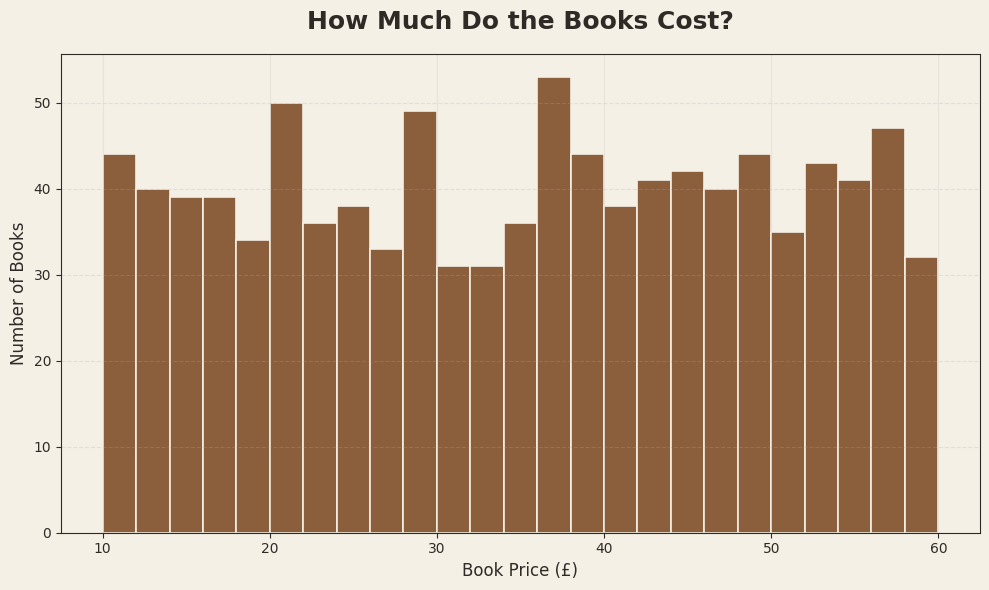

In [56]:

plt.figure(figsize=(10, 6))

plt.hist(
    df["Price_GBP"].dropna(),
    bins=25,
    color="#8B5E3C",
    edgecolor="#F5F0E6",
    linewidth=1.2
)

plt.title(
    "How Much Do the Books Cost?",
    fontsize=18,
    fontweight="bold",
    color="#2F2A26",
    pad=18
)

plt.xlabel("Book Price (£)", fontsize=12, color="#2F2A26")
plt.ylabel("Number of Books", fontsize=12, color="#2F2A26")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().set_facecolor("#F5F0E6")
plt.gcf().patch.set_facecolor("#F5F0E6")

plt.tight_layout()
plt.show()



### Interpretation

Use the histogram to determine whether most books are concentrated around a particular price range and whether a small number of expensive books create a long right tail.



## 8. Detect Potential Price Outliers

The IQR (Interquartile Range) method identifies observations that are unusually far from the middle 50% of the data.

An observation below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` is flagged as a potential outlier.


In [57]:

price_clean = df["Price_GBP"].dropna()

Q1 = price_clean.quantile(0.25)
Q3 = price_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Price_GBP"] < lower_bound) |
    (df["Price_GBP"] > upper_bound)
].copy()

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Lower outlier boundary: £{lower_bound:.2f}")
print(f"Upper outlier boundary: £{upper_bound:.2f}")
print(f"Potential outliers: {len(outliers)}")

display(outliers.sort_values("Price_GBP", ascending=False).head(10))


Q1: £22.11
Q3: £47.46
IQR: £25.35
Lower outlier boundary: £-15.92
Upper outlier boundary: £85.48
Potential outliers: 0


,Title,Price,Rating,Availability,Price_GBP


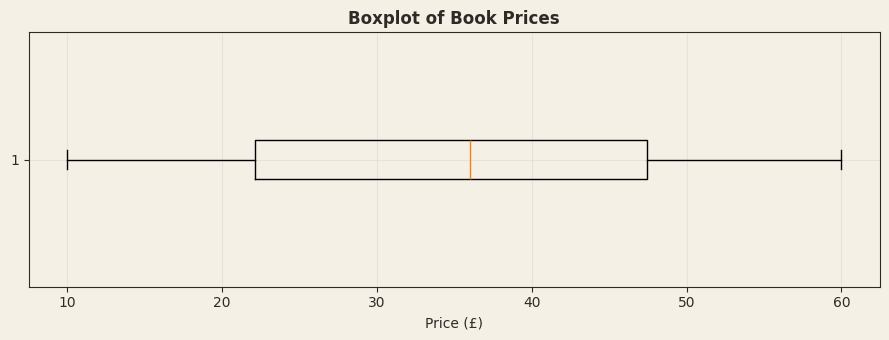

In [58]:

plt.figure(figsize=(9, 3.5))
plt.boxplot(price_clean, vert=False)
plt.xlabel("Price (£)")
plt.title("Boxplot of Book Prices")
plt.tight_layout()
plt.show()



### Important note

An outlier is not automatically an error. A high-priced book can be a legitimate observation. Outliers should therefore be investigated rather than automatically deleted.



## 9. Cheapest and Most Expensive Books

This identifies extreme observations and helps validate whether their values look reasonable.


In [59]:

title_col = next(
    (c for c in df.columns if c.strip().lower() in {"title", "book title", "name"}),
    None
)

if title_col:
    print("10 cheapest books:")
    display(df.nsmallest(10, "Price_GBP")[[title_col, "Price_GBP"]])

    print("10 most expensive books:")
    display(df.nlargest(10, "Price_GBP")[[title_col, "Price_GBP"]])
else:
    print("No title column was found, so only prices are displayed.")

    print("10 cheapest prices:")
    display(df.nsmallest(10, "Price_GBP")[["Price_GBP"]])

    print("10 most expensive prices:")
    display(df.nlargest(10, "Price_GBP")[["Price_GBP"]])


10 cheapest books:


,Title,Price_GBP
638,An Abundance of Katherines,10.00
501,The Origin of Species,10.01
716,The Tipping Point: How Little Things Can Make a Big Difference,10.02
84,Patience,10.16
302,Greek Mythic History,10.23
558,The Fellowship of the Ring (The Lord of the Rings #1),10.27
479,History of Beauty,10.29
242,The Lucifer Effect: Understanding How Good People Turn Evil,10.40
434,"NaNo What Now? Finding your editing process, revising your NaNoWriMo book and building a writing...",10.41
274,Pet Sematary,10.56


10 most expensive books:


,Title,Price_GBP
648,The Perfect Play (Play by Play #1),59.99
617,Last One Home (New Beginnings #1),59.98
860,Civilization and Its Discontents,59.95
560,The Barefoot Contessa Cookbook,59.92
366,The Diary of a Young Girl,59.90
657,The Bone Hunters (Lexy Vaughan & Steven Macaulay #2),59.71
133,Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History,59.64
387,Boar Island (Anna Pigeon #19),59.48
393,The Improbability of Love,59.45
549,The Man Who Mistook His Wife for a Hat and Other Clinical Tales,59.45



## 10. Explore Book Ratings

If the Task 1 dataset contains ratings, examine their frequency.

Ratings are converted to numbers from 1 to 5 when necessary.


In [60]:

rating_col = next(
    (c for c in df.columns if c.strip().lower() in {"rating", "book rating", "stars"}),
    None
)

if rating_col is None:
    print("No rating column was found in this Task 1 dataset.")
    print("The rating analysis and rating-price hypothesis test will be skipped.")
else:
    rating_map = {
        "One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5,
        "1": 1, "2": 2, "3": 3, "4": 4, "5": 5
    }

    df["Rating_Num"] = (
        df[rating_col]
        .astype(str)
        .str.strip()
        .map(rating_map)
    )

    print("Rating frequencies:")
    display(df["Rating_Num"].value_counts().sort_index().to_frame("Number of Books"))


Rating frequencies:


,Number of Books
Rating_Num,
1,226
2,196
3,203
4,179
5,196


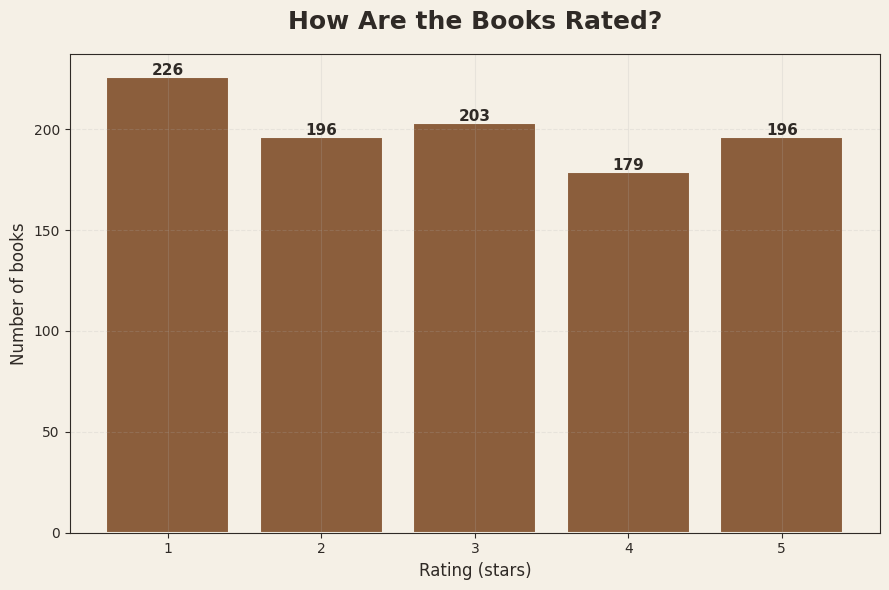

In [62]:
if "Rating_Num" in df.columns:
    rating_counts = df["Rating_Num"].value_counts().sort_index()

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        rating_counts.index.astype(str),
        rating_counts.values,
        color="#8B5E3C",
        edgecolor="#F5F0E6",
        linewidth=1.5
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{int(height)}",
            ha="center",
            fontsize=11,
            fontweight="bold"
        )

    plt.xlabel("Rating (stars)", fontsize=12)
    plt.ylabel("Number of books", fontsize=12)

    plt.title(
        "How Are the Books Rated?",
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    plt.grid(axis="y", linestyle="--", alpha=0.2)
    plt.gca().set_facecolor("#F5F0E6")
    plt.gcf().patch.set_facecolor("#F5F0E6")

    plt.tight_layout()
    plt.show()



## 11. Hypothesis Test: Rating vs. Price

### Research question

**Is there a statistically significant association between book rating and price?**

Because rating is an ordinal variable (1 to 5 stars), Spearman's rank correlation is appropriate.

### Hypotheses

- **H₀ (null hypothesis):** There is no monotonic association between book rating and price.
- **H₁ (alternative hypothesis):** There is a monotonic association between book rating and price.

We use a significance level of **α = 0.05**.


In [63]:

if "Rating_Num" in df.columns:
    test_data = df[["Rating_Num", "Price_GBP"]].dropna()

    rho, p_value = stats.spearmanr(
        test_data["Rating_Num"],
        test_data["Price_GBP"]
    )

    print(f"Spearman correlation (rho): {rho:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Decision: Reject H0.")
        print("Conclusion: There is statistically significant evidence of a monotonic association between rating and price.")
    else:
        print("Decision: Fail to reject H0.")
        print("Conclusion: There is not enough statistical evidence of a monotonic association between rating and price.")
else:
    print("Hypothesis test skipped because no rating variable is available.")


Spearman correlation (rho): 0.0292
p-value: 0.3560
Decision: Fail to reject H0.
Conclusion: There is not enough statistical evidence of a monotonic association between rating and price.


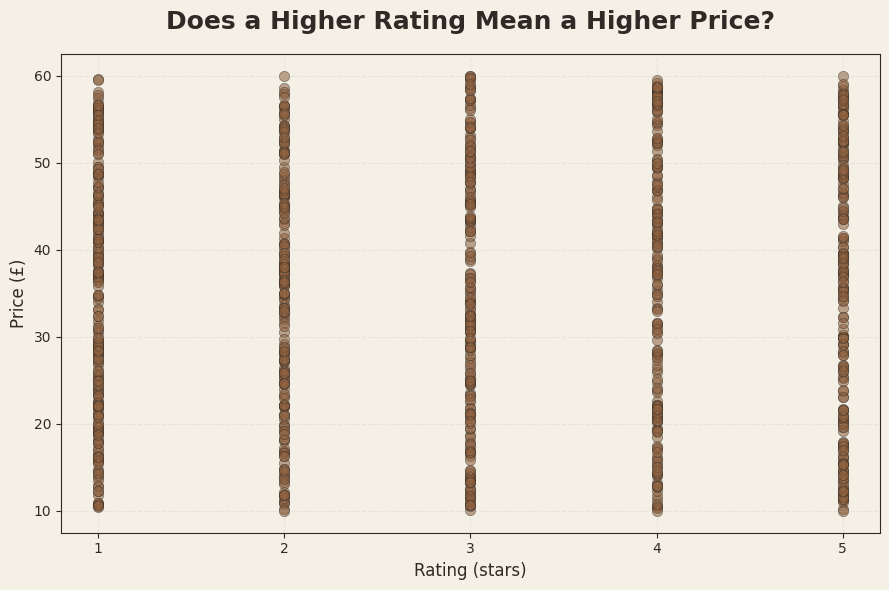

In [65]:

if "Rating_Num" in df.columns:

    plt.figure(figsize=(9, 6))

    plt.scatter(
        df["Rating_Num"],
        df["Price_GBP"],
        alpha=0.55,
        s=55,
        color="#8B5E3C",
        edgecolors="#2F2A26",
        linewidths=0.5
    )

    plt.xlabel("Rating (stars)", fontsize=12)
    plt.ylabel("Price (£)", fontsize=12)

    plt.title(
        "Does a Higher Rating Mean a Higher Price?",
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    plt.xticks([1, 2, 3, 4, 5])

    plt.grid(
        axis="both",
        linestyle="--",
        alpha=0.2
    )

    plt.gca().set_facecolor("#F5F0E6")
    plt.gcf().patch.set_facecolor("#F5F0E6")

    plt.tight_layout()
    plt.show()



## 12. Check for Data-Quality Problems

Potential issues include:

- missing values
- duplicate records
- non-numeric prices
- impossible or unexpected ratings
- inconsistent text values
- scraped values that need cleaning

The following checks summarize the main issues.


In [66]:

print("DATA QUALITY REPORT")
print("=" * 50)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values (total): {df.isna().sum().sum()}")
print(f"Invalid numeric prices: {df['Price_GBP'].isna().sum()}")

if "Rating_Num" in df.columns:
    invalid_ratings = (~df["Rating_Num"].isin([1, 2, 3, 4, 5]) & df["Rating_Num"].notna()).sum()
    print(f"Invalid ratings: {invalid_ratings}")

print("\nMissing values by column:")
display(df.isna().sum().to_frame("Missing Values"))


DATA QUALITY REPORT
Rows: 1000
Columns: 6
Duplicate rows: 0
Missing values (total): 0
Invalid numeric prices: 0
Invalid ratings: 0

Missing values by column:


,Missing Values
Title,0
Price,0
Rating,0
Availability,0
Price_GBP,0
Rating_Num,0



## 13. Summary of Findings

### Dataset structure
The dataset contains book-level observations collected from a public webpage. The analysis inspected its dimensions, variables, data types, missing values, and duplicate records.

### Price patterns
Descriptive statistics and visualizations show the center and spread of book prices. The histogram and boxplot can be used to identify skewness and potential extreme observations.

### Ratings
Where ratings are available, the bar chart shows how frequently each rating occurs.

### Hypothesis test
The Spearman correlation test evaluates whether rating and price have a statistically significant monotonic relationship. The numerical result printed above should be reported in the final submission.

### Data-quality issues
Potential issues identified by the checks above should be documented before performing more advanced analysis. In particular, scraped currency values need to be converted from text to numeric values, and potential outliers should be investigated rather than automatically removed.



## 14. Final Conclusion

This EDA provided an initial understanding of the scraped book dataset. The analysis examined the structure of the data, summarized book prices statistically, visualized their distribution, identified potential outliers, explored ratings, and tested the relationship between rating and price when rating data was available.
